<a href="https://colab.research.google.com/github/Leticiamendes0/https-github.com-evertonesaa-calculo-numerico-computacional-2026/blob/main/C%C3%B3pia_de_seminario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

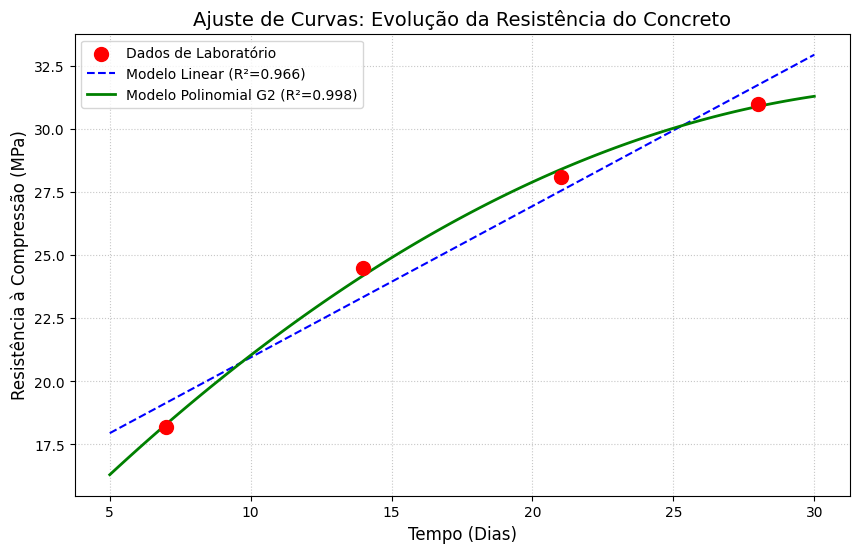

--- RESULTADOS MATEMÁTICOS ---
Equação Linear:  
0.6 x + 14.95
Equação Polinomial: 
          2
-0.01735 x + 1.207 x + 10.7
------------------------------
RMSE Linear: 0.8789
RMSE Polinomial: 0.2236


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# 1. ENTRADA DE DADOS (Ensaios de Laboratório)
# ==========================================
dias = np.array([7, 14, 21, 28])
resistencia = np.array([18.2, 24.5, 28.1, 31.0]) # Valores reais em MPa

# ==========================================
# 2. AJUSTE DE CURVAS (Cálculo Numérico)
# ==========================================

# Ajuste Linear (Grau 1): y = ax + b
coef1 = np.polyfit(dias, resistencia, 1)
p1 = np.poly1d(coef1)

# Ajuste Polinomial (Grau 2): y = ax² + bx + c
coef2 = np.polyfit(dias, resistencia, 2)
p2 = np.poly1d(coef2)

# Criando pontos intermediários para uma curva suave no gráfico
x_curva = np.linspace(min(dias)-2, max(dias)+2, 100)

# ==========================================
# 3. ANÁLISE ESTATÍSTICA (Métricas de Erro)
# ==========================================

# R² (Quanto mais próximo de 1, melhor)
r2_lin = r2_score(resistencia, p1(dias))
r2_poly = r2_score(resistencia, p2(dias))

# Erro Quadrático Médio (Quanto menor, melhor)
rmse_lin = np.sqrt(mean_squared_error(resistencia, p1(dias)))
rmse_poly = np.sqrt(mean_squared_error(resistencia, p2(dias)))

# ==========================================
# 4. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
plt.figure(figsize=(10, 6))

# Pontos experimentais
plt.scatter(dias, resistencia, color='red', s=100, label='Dados de Laboratório', zorder=5)

# Linha da Regressão Linear
plt.plot(x_curva, p1(x_curva), '--', color='blue', label=f'Modelo Linear (R²={r2_lin:.3f})')

# Linha da Regressão Polinomial
plt.plot(x_curva, p2(x_curva), color='green', linewidth=2, label=f'Modelo Polinomial G2 (R²={r2_poly:.3f})')

# Customização do Gráfico
plt.title('Ajuste de Curvas: Evolução da Resistência do Concreto', fontsize=14)
plt.xlabel('Tempo (Dias)', fontsize=12)
plt.ylabel('Resistência à Compressão (MPa)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# ==========================================
# 5. PRINT DOS RESULTADOS PARA O SLIDE
# ==========================================
print("--- RESULTADOS MATEMÁTICOS ---")
print(f"Equação Linear: {p1}")
print(f"Equação Polinomial: \n{p2}")
print("-" * 30)
print(f"RMSE Linear: {rmse_lin:.4f}")
print(f"RMSE Polinomial: {rmse_poly:.4f}")